In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

path = kagglehub.dataset_download("shayanfazeli/heartbeat")
warnings.filterwarnings('ignore')
mitbih_train = pd.read_csv(path + '/mitbih_train.csv')
mitbih_test = pd.read_csv(path + '/mitbih_test.csv')

100%|██████████| 98.8M/98.8M [00:09<00:00, 11.1MB/s]

Extracting model files...


In [2]:
print("mitbih train:", mitbih_train.shape)
print("mit bih test:", mitbih_test.shape)

mitbih train: (87553, 188)
mit bih test: (21891, 188)


In [3]:
mitbih_train.sample(n=15, random_state=42)

,9.779411554336547852e-01,9.264705777168273926e-01,6.813725233078002930e-01,2.450980395078659058e-01,1.544117629528045654e-01,1.911764740943908691e-01,1.519607901573181152e-01,8.578431606292724609e-02,5.882352963089942932e-02,4.901960864663124084e-02,...,0.000000000000000000e+00.79,0.000000000000000000e+00.80,0.000000000000000000e+00.81,0.000000000000000000e+00.82,0.000000000000000000e+00.83,0.000000000000000000e+00.84,0.000000000000000000e+00.85,0.000000000000000000e+00.86,0.000000000000000000e+00.87,0.000000000000000000e+00.88
10563,0.938776,0.895408,0.721939,0.290816,0.125000,0.150510,0.137755,0.058673,0.045918,0.040816,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25843,1.000000,0.708609,0.064018,0.050773,0.145695,0.088300,0.057395,0.055188,0.050773,0.046358,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15891,1.000000,0.856153,0.568458,0.292894,0.091854,0.058925,0.098787,0.124783,0.126516,0.124783,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
62606,0.992331,0.815951,0.226994,0.019939,0.256135,0.325153,0.302147,0.294479,0.299080,0.299080,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84282,0.868590,0.448718,0.490385,0.477564,0.461538,0.455128,0.416667,0.304487,0.182692,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
54806,0.960894,0.527933,0.363128,0.220670,0.134078,0.069832,0.058659,0.047486,0.041899,0.041899,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71243,0.401786,0.946429,0.910714,0.000000,0.107143,0.446429,0.535714,0.526786,0.526786,0.553571,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
85831,0.730769,0.628205,0.532764,0.408832,0.282051,0.152422,0.072650,0.000000,0.000000,0.017094,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
83962,0.863014,0.523973,0.503425,0.534247,0.541096,0.523973,0.510274,0.472603,0.369863,0.280822,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
61428,0.968858,0.553633,0.000000,0.048443,0.069204,0.072664,0.076125,0.065744,0.076125,0.083045,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
print(mitbih_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87553 entries, 0 to 87552
Columns: 188 entries, 9.779411554336547852e-01 to 0.000000000000000000e+00.88
dtypes: float64(188)
memory usage: 125.6 MB
None


In [5]:
mitbih_train.describe()

,9.779411554336547852e-01,9.264705777168273926e-01,6.813725233078002930e-01,2.450980395078659058e-01,1.544117629528045654e-01,1.911764740943908691e-01,1.519607901573181152e-01,8.578431606292724609e-02,5.882352963089942932e-02,4.901960864663124084e-02,...,0.000000000000000000e+00.79,0.000000000000000000e+00.80,0.000000000000000000e+00.81,0.000000000000000000e+00.82,0.000000000000000000e+00.83,0.000000000000000000e+00.84,0.000000000000000000e+00.85,0.000000000000000000e+00.86,0.000000000000000000e+00.87,0.000000000000000000e+00.88
count,87553.000000,87553.000000,87553.000000,87553.000000,87553.000000,87553.000000,87553.000000,87553.000000,87553.000000,87553.000000,...,87553.000000,87553.000000,87553.000000,87553.000000,87553.000000,87553.000000,87553.000000,87553.000000,87553.000000,87553.000000
mean,0.890359,0.758158,0.423969,0.219104,0.201127,0.210399,0.205809,0.201774,0.198693,0.196758,...,0.005025,0.004628,0.004291,0.003945,0.003681,0.003471,0.003221,0.002945,0.002807,0.473382
std,0.240910,0.221814,0.227305,0.206880,0.177058,0.171910,0.178482,0.177241,0.171778,0.168358,...,0.044155,0.042089,0.040525,0.038651,0.037193,0.036255,0.034790,0.032865,0.031924,1.143190
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.921922,0.682482,0.250965,0.048458,0.082329,0.088415,0.073333,0.066116,0.065000,0.068643,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.991342,0.826007,0.429467,0.165992,0.147870,0.158798,0.145320,0.144424,0.150000,0.148734,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.910506,0.578767,0.341727,0.258993,0.287634,0.298246,0.295393,0.290837,0.283636,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000


In [6]:
mitbih_test.describe()

,1.000000000000000000e+00,7.582644820213317871e-01,1.115702465176582336e-01,0.000000000000000000e+00,8.057851344347000122e-02,7.851240038871765137e-02,6.611569970846176147e-02,4.958677664399147034e-02,4.752065986394882202e-02,3.512396663427352905e-02,...,0.000000000000000000e+00.56,0.000000000000000000e+00.57,0.000000000000000000e+00.58,0.000000000000000000e+00.59,0.000000000000000000e+00.60,0.000000000000000000e+00.61,0.000000000000000000e+00.62,0.000000000000000000e+00.63,0.000000000000000000e+00.64,0.000000000000000000e+00.65
count,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,...,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000,21891.000000
mean,0.894405,0.761902,0.426641,0.221606,0.201682,0.209897,0.204811,0.200999,0.197640,0.196030,...,0.004588,0.004328,0.004020,0.003789,0.003639,0.003459,0.003167,0.003000,0.002946,0.473711
std,0.234564,0.218664,0.228568,0.208710,0.177730,0.172195,0.177948,0.176143,0.170229,0.166707,...,0.043129,0.042188,0.040256,0.039398,0.038536,0.037718,0.035904,0.035523,0.035267,1.143469
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.924254,0.683355,0.251220,0.050514,0.082873,0.087912,0.072678,0.066003,0.064516,0.068506,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.990431,0.828996,0.432781,0.167641,0.147651,0.158120,0.144068,0.144509,0.150442,0.149038,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.912320,0.583994,0.347097,0.259227,0.287356,0.298456,0.294566,0.289907,0.282966,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.991429,...,0.980392,1.000000,0.966102,1.000000,1.000000,1.000000,1.000000,0.996053,1.000000,4.000000


In [11]:
mitbih_train.columns

Index(['9.779411554336547852e-01', '9.264705777168273926e-01',
       '6.813725233078002930e-01', '2.450980395078659058e-01',
       '1.544117629528045654e-01', '1.911764740943908691e-01',
       '1.519607901573181152e-01', '8.578431606292724609e-02',
       '5.882352963089942932e-02', '4.901960864663124084e-02',
       ...
       '0.000000000000000000e+00.79', '0.000000000000000000e+00.80',
       '0.000000000000000000e+00.81', '0.000000000000000000e+00.82',
       '0.000000000000000000e+00.83', '0.000000000000000000e+00.84',
       '0.000000000000000000e+00.85', '0.000000000000000000e+00.86',
       '0.000000000000000000e+00.87', '0.000000000000000000e+00.88'],
      dtype='object', length=188)

In [15]:
mitbih_train.iloc[:,-1].value_counts()

0.000000000000000000e+00.88
0.0    72470
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64

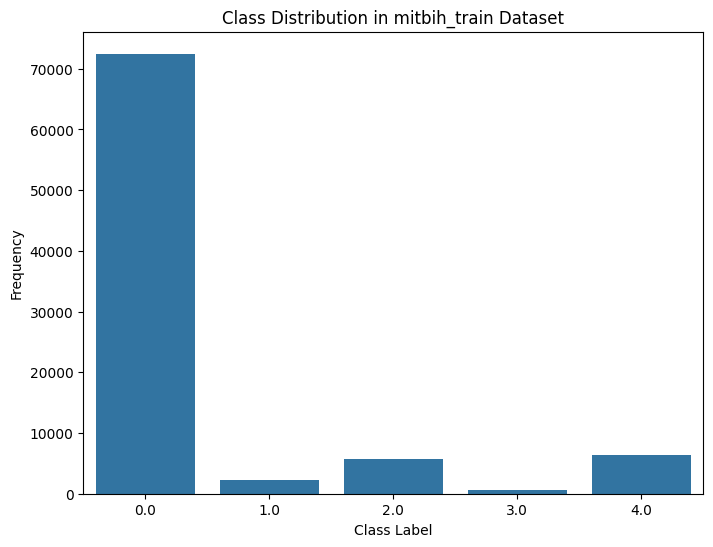

In [41]:
plt.figure(figsize=(8, 6))
sns.countplot(x='0.000000000000000000e+00.88', data=mitbih_train)
plt.title('Class Distribution in mitbih_train Dataset')
plt.xlabel('Class Label')
plt.ylabel('Frequency')
plt.show()

Heavy class imbalance, least ammount of class 3 labels with only 600 cases compared to 0 with 72 thousand, with model training arises need for haevy augmentation or loss adjustment

In [16]:
import librosa
import librosa.display

def extract_features(data):
    features = []
    for index, row in data.iterrows():
        signal = row.values[:-1]
        signal = np.array(signal, dtype=float)

        mean_val = np.mean(signal)

        median_val = np.median(signal)

        std_val = np.std(signal)

        # Fourier
        fft_coefficients = np.fft.fft(signal)
        fft_coefficients = np.abs(fft_coefficients)
        fft_features = fft_coefficients[:1000]

        # MFCC
        sr = 1000
        mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
        mfcc_features = np.mean(mfccs, axis=1)

        features.append(np.concatenate([ [mean_val, median_val, std_val], fft_features, mfcc_features ]))

    return np.array(features)

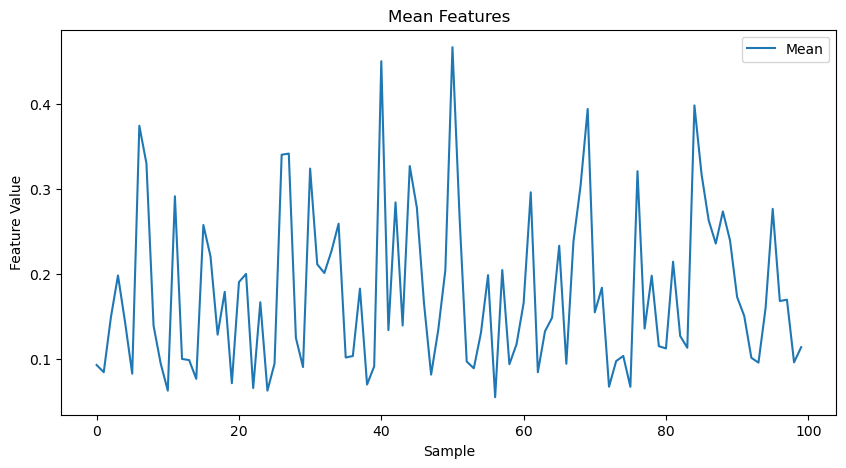

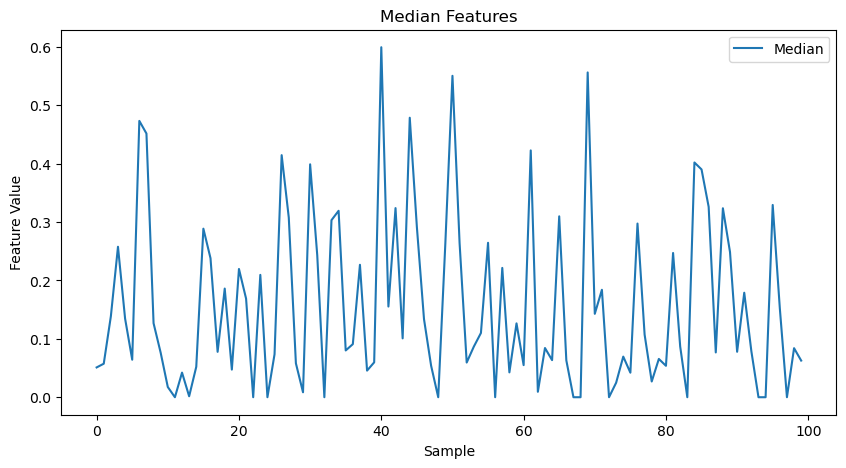

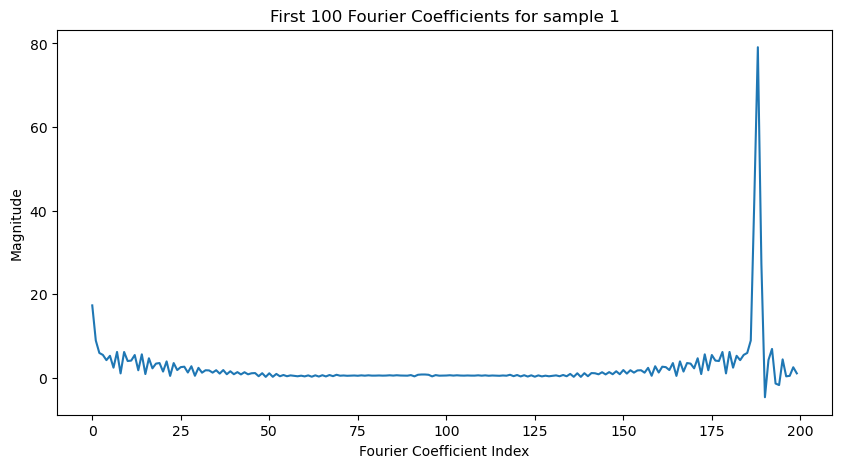

In [17]:
train_data_subset = mitbih_train.sample(n=1000, random_state=42)
extracted_features = extract_features(train_data_subset)

plt.figure(figsize=(10, 5))
plt.plot(range(100), extracted_features[:100, 0], label="Mean")
plt.xlabel("Sample")
plt.ylabel("Feature Value")
plt.legend()
plt.title("Mean Features")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(range(100), extracted_features[:100, 1], label="Median")
plt.xlabel("Sample")
plt.ylabel("Feature Value")
plt.legend()
plt.title("Median Features")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(extracted_features[0, 3:1003])
plt.title("First 100 Fourier Coefficients for sample 1")
plt.xlabel("Fourier Coefficient Index")
plt.ylabel("Magnitude")
plt.show()

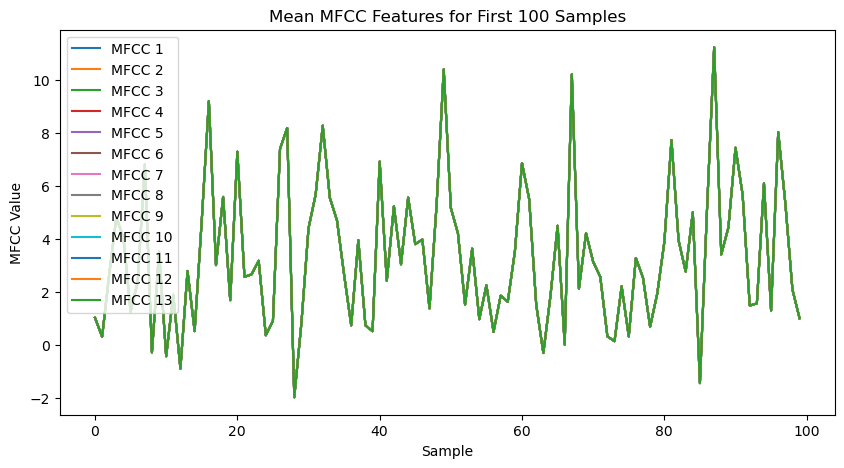

In [18]:
plt.figure(figsize=(10, 5))
for i in range(13):
    plt.plot(range(100), extracted_features[:100, 202], label=f"MFCC {i+1}")

plt.xlabel("Sample")
plt.ylabel("MFCC Value")
plt.legend()
plt.title("Mean MFCC Features for First 100 Samples")
plt.show()

Извлечение и поиск релевантных признаков:

Среднее, медиана

Коэффициенты Фурье

MFCC
